# importing libraries

from nltk.tokenize import sent_tokenize
from nltk.tokenize.treebank import TreebankWordTokenizer
import nltk
#nltk.download('punkt')
import glob
from pathlib import Path
import os
import gensim
import pandas as pd
from gensim.models import Word2Vec
from matplotlib import pyplot as plt 
#import tsne

In [2]:
#identifying folder

import os
base_dir = "/media/secure_volume/Temple_Workset_June/"
all_docs = []
docs = os.listdir(base_dir)

In [3]:
#Making sure I can read through

for doc in docs:
    filename = os.fsdecode(doc)
    if not doc.startswith('.'):
        print(os.path.join(base_dir, filename))

/media/secure_volume/Temple_Workset_June/ppt.ssfcbz201710000389.txt
/media/secure_volume/Temple_Workset_June/ppt.ssfcbz202002001067.txt
/media/secure_volume/Temple_Workset_June/ppt.ssfcbz201710000330.txt
/media/secure_volume/Temple_Workset_June/ppt.ssfcbz201808000100.txt
/media/secure_volume/Temple_Workset_June/ppt.ssfcbz201808000041.txt
/media/secure_volume/Temple_Workset_June/ppt.ssfcbz202002001014.txt
/media/secure_volume/Temple_Workset_June/ppt.ssfcbz201710000437.txt
/media/secure_volume/Temple_Workset_June/ppt.ssfcbz202002001020.txt
/media/secure_volume/Temple_Workset_June/ppt.ssfcbz201710000360.txt
/media/secure_volume/Temple_Workset_June/ppt.ssfcbz201710000414.txt
/media/secure_volume/Temple_Workset_June/ppt.ssfcbz201710000355.txt
/media/secure_volume/Temple_Workset_June/ppt.ssfcbz201808000112.txt
/media/secure_volume/Temple_Workset_June/ppt.ssfcbz201808000072.txt
/media/secure_volume/Temple_Workset_June/ppt.ssfcbz201710000333.txt
/media/secure_volume/Temple_Workset_June/ppt.ssf

In [4]:
#Reading through and checking

for doc in docs:
    if not doc.startswith('.'):
        with open(base_dir + doc, "r", encoding="utf-8") as file:
            text = file.read()
            all_docs.append(text)
            

len(all_docs)

349

In [5]:
tokenizer = TreebankWordTokenizer()

In [6]:
import glob
files = glob.glob(f"{base_dir}/.txt")

In [7]:
titles = [Path(file).stem for file in files]

In [8]:
#make text lower-case and tokenize
def make_sentences_Temple(list_text):
    all_txt = []
    counter = 0
    for txt in list_text:
        lower_txt = txt.lower()
        sentences = sent_tokenize(lower_txt)
        sentences = [tokenizer.tokenize(sent) for sent in sentences]
        all_txt += sentences
        print(len(sentences))
        print("\n")
        counter += 1
    return all_txt

In [9]:
sentences = make_sentences_Temple(all_docs)

5169


6348


3438


4315


3135


3389


3786


4906


5474


3697


4856


4309


3217


3117


4342


4127


2498


3979


3110


7402


6327


2921


4475


6473


6473


4842


4186


3431


2435


3975


4325


2831


7621


5917


4656


3255


5275


2911


3148


3767


4383


2349


4220


4400


3181


4283


2375


5004


3825


4195


2918


3342


4183


13397


1963


3095


5024


2283


1546


5205


4532


6184


4992


4075


4956


24515


3762


7125


3721


4262


2951


3004


6784


5242


10390


8371


3120


2758


3479


4226


3404


3872


3364


5458


4123


5090


3150


3708


2


5881


3928


3228


5896


5523


4794


4323


2377


2911


4180


4139


5052


5375


5565


5264


4234


3659


3856


5767


3509


3282


2803


4192


3110


4850


1618


3893


3991


3895


3643


2235


3527


3323


8790


5804


3631


6390


4260


3290


4781


3680


2821


4755


5701


4570


4632


2561


3289


3544


5363


3295


4582


3007


4201



In [1]:
Temple_model=gensim.models.Word2Vec(
sentences,
min_count=2,
vector_size=300,
workers=5)

NameError: name 'gensim' is not defined

In [11]:
Temple_model.save("Temple_model")

In [12]:
Temple_model.wv.most_similar("river", topn=5)

[('lake', 0.8248650431632996),
 ('valley', 0.8170360326766968),
 ('creek', 0.7898335456848145),
 ('road', 0.7794109582901001),
 ('meadow', 0.7750329971313477)]

In [13]:
Temple_model.wv.most_similar("ocean", topn=5)

[('sea', 0.800800621509552),
 ('waters', 0.7844966053962708),
 ('seas', 0.775905191898346),
 ('desert', 0.7734566330909729),
 ('oceans', 0.7629917860031128)]

In [14]:
Temple_model.wv.most_similar("sea", topn=5)

[('waters', 0.8068690299987793),
 ('desert', 0.8036508560180664),
 ('ocean', 0.800800621509552),
 ('lake', 0.7499553561210632),
 ('seas', 0.7482688426971436)]

In [40]:
Temple_model.wv.most_similar("pollution", topn=5)

[('warfare', 0.6814908385276794),
 ('conditioning', 0.6692883968353271),
 ('planetary', 0.6479378342628479),
 ('petroleum', 0.6445519328117371),
 ('combustion', 0.6354142427444458)]

In [16]:
Temple_model.wv.similarity('ocean','sewage')

0.18685973

In [17]:
Temple_model.wv.similarity('river','sewage')

0.27991757

In [18]:
Temple_model.wv.similarity('ocean','pollution')

0.3562598

In [19]:
Temple_model.wv.similarity('river','pollution')

0.18685973

In [23]:
result = Temple_model.wv.most_similar(positive=['water', 'drink'], negative=['river'])
print("{}: {:.4f}".format(*result[0]))

tea: 0.6893


In [24]:
result = Temple_model.wv.most_similar(positive=['river', 'canal'], negative=['ocean'])
print("{}: {:.4f}".format(*result[0]))

highway: 0.7513


In [25]:
result = Temple_model.wv.most_similar(positive=['road', 'travel'], negative=['river'])
print("{}: {:.4f}".format(*result[0]))

operate: 0.5838


In [30]:
result = Temple_model.wv.most_similar(positive=['river', 'flood'], negative=['ocean'])
print("{}: {:.4f}".format(*result[0]))

torrent: 0.6010


In [31]:
Temple_model.wv.most_similar("water", topn=5)

[('liquid', 0.7053585648536682),
 ('moisture', 0.6726253032684326),
 ('waters', 0.6578226685523987),
 ('salt', 0.6535181403160095),
 ('ice', 0.6528480052947998)]

In [32]:
Temple_model.wv.most_similar("toxic", topn=5)

[('poisonous', 0.7253320813179016),
 ('poisoning', 0.6874942183494568),
 ('radioactive', 0.6728153228759766),
 ('synthetic', 0.6591303944587708),
 ('crystalline', 0.649424135684967)]

In [33]:
Temple_model.wv.most_similar("creek", topn=5)

[('canyon', 0.8207700252532959),
 ('meadow', 0.7904289960861206),
 ('river', 0.7898334860801697),
 ('brook', 0.7696917057037354),
 ('lake', 0.7613804340362549)]

In [36]:
from sklearn.manifold import TSNE
import numpy as np

In [38]:
print(similar_words)

[['lake', 'valley', 'creek', 'road', 'meadow'], ['liquid', 'moisture', 'waters', 'salt', 'ice'], ['manufacturing', 'petroleum', 'warfare', 'breathable', 'poisoning'], ['poisonous', 'poisoning', 'radioactive', 'synthetic', 'crystalline']]


In [37]:
#Add base words and similar words to graph
base_words = ['river', 'water', 'pollution', 'toxic']

num_similar_words = 5

word_vectors = []
similar_words = []

for word in base_words:
    word_vectors.append(Temple_model.wv[word])
    similar = Temple_model.wv.most_similar(word, topn=num_similar_words)
    similar_words.append([w[0] for w in similar])


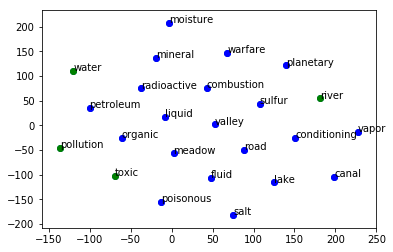

In [140]:
#Flatten vectors and combine lists
word_vectors = np.array(word_vectors)
word_vectors_flat = word_vectors.reshape(-1, word_vectors.shape[-1])
similar_words_flat = [w for sublist in similar_words for w in sublist]

combined_vectors = np.vstack([word_vectors_flat, Temple_model.wv[similar_words_flat]])
combined_words = base_words + similar_words_flat,

tsne = TSNE(n_components = 2)
combined_vectors_tsne = tsne.fit_transform(combined_vectors)

#Plot words and similar words in same plot
plt.scatter(combined_vectors_tsne[:,0], combined_vectors_tsne[:,1])

#Annotate plot with base and most simliar words
for i, word in enumerate(combined_words):
    plt.annotate(word, (combined_vectors_tsne[i,0], combined_vectors_tsne[i,1]))

    x=combined_vectors_tsne[i,0]
    y=combined_vectors_tsne[i,1]

    if word in base_words:
        plt.scatter(x, y, color='green')
    else:
        plt.scatter(x, y, color='blue')


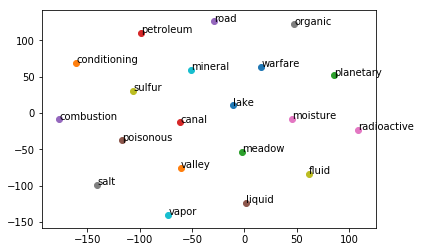

In [88]:
#choose words you want to plot
similar1 = Temple_model.wv.most_similar("river", topn=5)
similar2 = Temple_model.wv.most_similar("water", topn=5)
similar3 = Temple_model.wv.most_similar("pollution", topn=5)
similar4 = Temple_model.wv.most_similar("toxic", topn=5)

similar_words = similar1, similar2, similar3, similar4
similar_words = [element for nestedlist in similar_words for element in nestedlist]

#get vectors of words
vectors = np.zeros((len(similar_words), Temple_model.vector_size)) 
for i, (word, sim) in enumerate(similar_words):
        vectors[i] = Temple_model.wv[word]
        
#reduce dimensionality of vectors using TSNE
tsne = TSNE(n_components=2, random_state=0)
vectors_tsne = tsne.fit_transform(vectors)

#Plot the points with the corresponding labels
fig, ax = plt.subplots()
for i, (word, sim) in enumerate(similar_words):
    ax.scatter(vectors_tsne[i,0], vectors_tsne[i, 1])
    ax.annotate(word, (vectors_tsne[i, 0], vectors_tsne[i, 1]))
    
#show the polot
plt.show()

In [ ]:
import numpy as np
from sklearn.manifold import TSNE